# Pollen Image Brightness Enhancement

## Project Overview

This notebook applies an intensity transformation method to improve the perceived brightness of the image `pollen-500x430px-96dpi.jpg`.

The image is a grayscale microscopy image, where each pixel is represented by a single intensity value. In an 8-bit grayscale image, pixel intensities range from 0 to 255:

- `I(x, y) = 0` corresponds to black,
- `I(x, y) = 255` corresponds to white,
- intermediate values correspond to different gray levels.

The image appears relatively dark because many pixels are concentrated in the low and mid-intensity range. Therefore, an appropriate enhancement method should increase the brightness of dark and mid-tone pixels while preserving the structural details of the pollen grains.

## Proposed Method: Gamma Correction / Power-Law Transformation

The method proposed is **gamma correction**, also known as a **power-law intensity transformation**.

This is a **point operation in the spatial domain**.

It is a point operation because the output value of each pixel depends only on the corresponding input pixel value and not on neighbouring pixels.

Mathematically:

$$
s(x,y) = T(r(x,y))
$$

where:

- \(r(x,y)\) is the normalized input intensity of the pixel at position \((x,y)\),
- \(s(x,y)\) is the normalized output intensity after transformation,
- \(T\) is the intensity transformation function.

The input image is first normalized from the range \([0,255]\) to the range \([0,1]\):

$$
r(x,y) = \frac{I(x,y)}{255}
$$

The gamma correction transformation is then applied:

$$
s(x,y) = r(x,y)^{1/\gamma}
$$

with:

$$
\gamma > 1
$$

In this implementation, the value used is:

$$
\gamma = 1.8
$$

Since:

$$
\gamma > 1 \Rightarrow \frac{1}{\gamma} < 1
$$

then, for pixel values in the interval:

$$
0 < r < 1
$$

we obtain:

$$
r^{1/\gamma} > r
$$

Therefore, dark and mid-tone pixels become brighter.

For example, if:

$$
r = 0.25, \quad \gamma = 1.8
$$

then:

$$
s = 0.25^{1/1.8} \approx 0.463
$$

This means that a pixel with normalized intensity 0.25 becomes approximately 0.463 after gamma correction, so it becomes brighter.

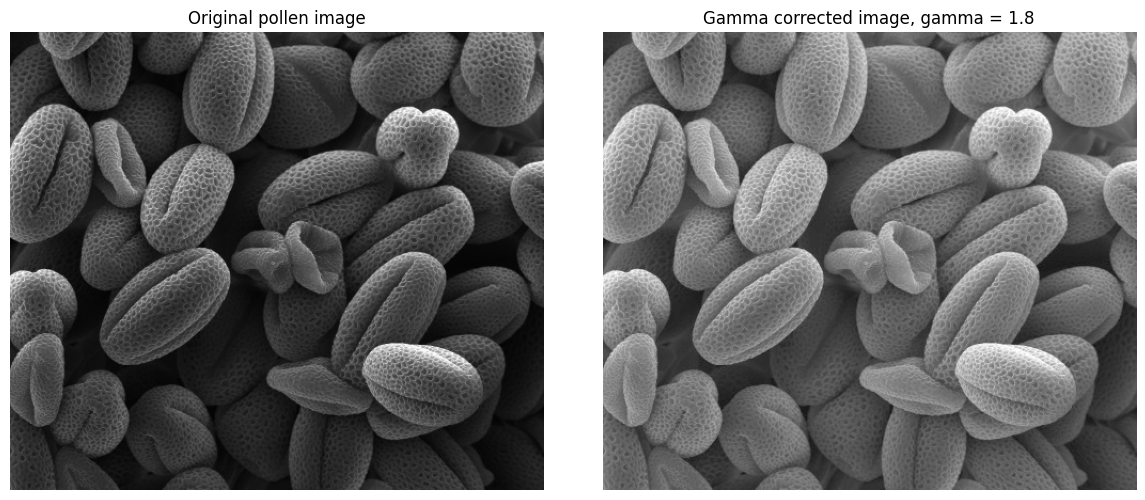

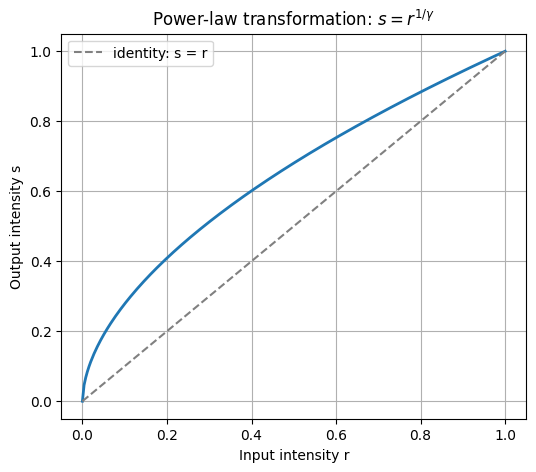

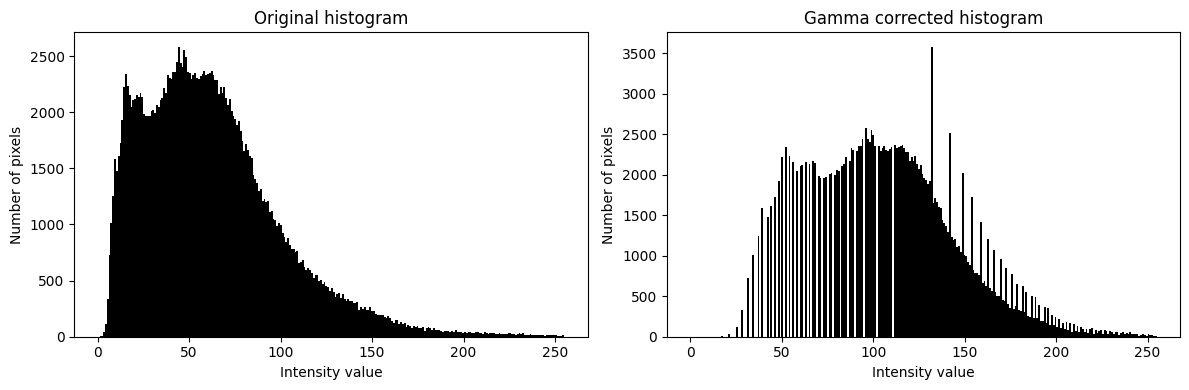

Original image:
Min intensity: 1
Max intensity: 255
Mean intensity: 62.11
Standard deviation: 38.39

Gamma corrected image:
Min intensity: 11
Max intensity: 255
Mean intensity: 110.36
Standard deviation: 39.47

Example normalized mappings r -> s:
r = 0.05 -> s = 0.189
r = 0.10 -> s = 0.278
r = 0.25 -> s = 0.463
r = 0.50 -> s = 0.680
r = 0.75 -> s = 0.852
r = 1.00 -> s = 1.000

Conclusion:
Gamma correction with gamma > 1 increases the perceived brightness of dark and mid-tone pixels.
It is a point operation in the spatial domain, since each output pixel depends only on the corresponding input pixel.
The result should make the pollen structures more visible without simply adding a constant intensity to all pixels.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Gamma correction / Power-law transformation
# Image: pollen
# ---------------------------------------------------------

IMAGE_PATH = Path(r"pollen-500x430px-96dpi.jpg")   # change this if needed

if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

# Safe loading, also works with Greek/Unicode paths on Windows
image_bytes = np.fromfile(str(IMAGE_PATH), dtype=np.uint8)
img = cv2.imdecode(image_bytes, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("The image could not be loaded. Check the file path or file integrity.")

# ---------------------------------------------------------
# 1. Normalize intensity values to [0, 1]
# ---------------------------------------------------------
r = img.astype(np.float32) / 255.0

# ---------------------------------------------------------
# 2. Apply gamma correction
# s = r^(1/gamma), with gamma > 1
# This increases perceived brightness.
# ---------------------------------------------------------
gamma = 1.8
s = np.power(r, 1.0 / gamma)

# Convert back to uint8 image in [0, 255]
img_gamma = np.clip(s * 255, 0, 255).astype(np.uint8)

# ---------------------------------------------------------
# 3. Display original and enhanced image
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original pollen image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_gamma, cmap="gray", vmin=0, vmax=255)
plt.title(f"Gamma corrected image, gamma = {gamma}")
plt.axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Show the transformation function s = T(r)
# ---------------------------------------------------------
x = np.linspace(0, 1, 256)
y = np.power(x, 1.0 / gamma)

plt.figure(figsize=(6, 5))
plt.plot(x, y, linewidth=2)
plt.plot(x, x, "--", color="gray", label="identity: s = r")
plt.title(r"Power-law transformation: $s = r^{1/\gamma}$")
plt.xlabel("Input intensity r")
plt.ylabel("Output intensity s")
plt.grid(True)
plt.legend()
plt.show()

# ---------------------------------------------------------
# 5. Histograms before and after
# ---------------------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=(0, 255), color="black")
plt.title("Original histogram")
plt.xlabel("Intensity value")
plt.ylabel("Number of pixels")

plt.subplot(1, 2, 2)
plt.hist(img_gamma.ravel(), bins=256, range=(0, 255), color="black")
plt.title("Gamma corrected histogram")
plt.xlabel("Intensity value")
plt.ylabel("Number of pixels")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. Numerical confirmation
# ---------------------------------------------------------
print("Original image:")
print("Min intensity:", img.min())
print("Max intensity:", img.max())
print("Mean intensity:", round(float(img.mean()), 2))
print("Standard deviation:", round(float(img.std()), 2))

print("\nGamma corrected image:")
print("Min intensity:", img_gamma.min())
print("Max intensity:", img_gamma.max())
print("Mean intensity:", round(float(img_gamma.mean()), 2))
print("Standard deviation:", round(float(img_gamma.std()), 2))

print("\nExample normalized mappings r -> s:")
for value in [0.05, 0.10, 0.25, 0.50, 0.75, 1.00]:
    out = value ** (1.0 / gamma)
    print(f"r = {value:.2f} -> s = {out:.3f}")

print("\nConclusion:")
print("Gamma correction with gamma > 1 increases the perceived brightness of dark and mid-tone pixels.")
print("It is a point operation in the spatial domain, since each output pixel depends only on the corresponding input pixel.")
print("The result should make the pollen structures more visible without simply adding a constant intensity to all pixels.")


## Results and Interpretation of Gamma Correction

The first code cell applies gamma correction to the pollen image using:

$$
s = r^{1/\gamma}
$$

with:

$$
\gamma = 1.8
$$

The original image has the following statistics:

$$
\text{minimum intensity} = 1
$$

$$
\text{maximum intensity} = 255
$$

$$
\text{mean intensity} = 62.11
$$

$$
\text{standard deviation} = 38.39
$$

The low mean intensity confirms that the original image is relatively dark. This is also visible in the original histogram, where most pixels are concentrated in the low and mid-intensity range.

After gamma correction, the image has the following statistics:

$$
\text{minimum intensity} = 11
$$

$$
\text{maximum intensity} = 255
$$

$$
\text{mean intensity} = 110.36
$$

$$
\text{standard deviation} = 39.47
$$

The mean intensity increases from:

$$
62.11 \rightarrow 110.36
$$

This confirms quantitatively that the image has become brighter.

The minimum intensity also increases from:

$$
1 \rightarrow 11
$$

which means that even the darkest pixels have been brightened.

The maximum intensity remains:

$$
255
$$

because pixels that are already at the maximum possible brightness cannot be increased further.

The standard deviation changes only slightly:

$$
38.39 \rightarrow 39.47
$$

This indicates that gamma correction mainly increases brightness while preserving the overall contrast structure of the image. It does not aggressively redistribute the intensity values.

The normalized mappings printed by the code also confirm the mathematical behaviour of the transformation:

$$
0.05 \rightarrow 0.189
$$

$$
0.10 \rightarrow 0.278
$$

$$
0.25 \rightarrow 0.463
$$

$$
0.50 \rightarrow 0.680
$$

$$
0.75 \rightarrow 0.852
$$

$$
1.00 \rightarrow 1.000
$$

For all values:

$$
0 < r < 1
$$

the output value is larger than the input value:

$$
s > r
$$

Thus, the gamma correction transformation increases the perceived brightness of dark and mid-tone pixels.

The histogram after gamma correction is shifted to the right compared with the original histogram. This shows that pixel intensities have increased. However, the transformation remains smooth and controlled, preserving the visible structure and texture of the pollen grains.

Therefore, gamma correction successfully improves the perceived brightness of the image while maintaining its important structural details.

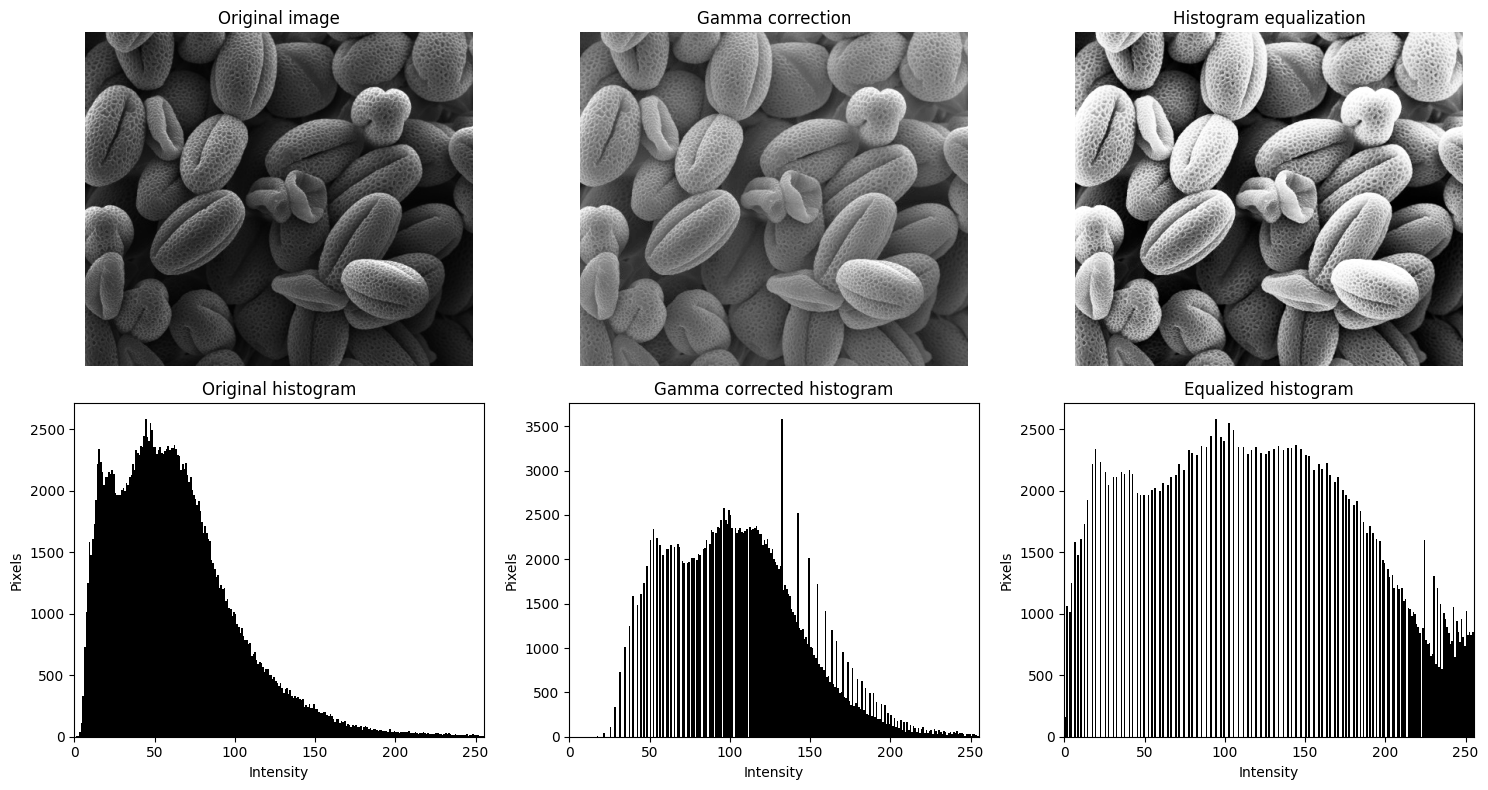

Numerical comparison:
Original mean: 62.11 | std: 38.39
Gamma mean: 110.36 | std: 39.47
Hist. equalization mean: 128.58 | std: 73.33

Conclusion:
Gamma correction mainly increases perceived brightness in a smooth, nonlinear way.
Histogram equalization spreads intensity values more aggressively over the full range.
Gamma correction is more appropriate here because the goal is perceived brightness enhancement, not maximum contrast redistribution.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Optional comparison: Gamma Correction vs Histogram Equalization
# ---------------------------------------------------------

img_equalized = cv2.equalizeHist(img)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img_gamma, cmap="gray", vmin=0, vmax=255)
plt.title("Gamma correction")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(img_equalized, cmap="gray", vmin=0, vmax=255)
plt.title("Histogram equalization")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.hist(img.ravel(), bins=256, range=(0, 256), color="black")
plt.title("Original histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixels")
plt.xlim([0, 255])

plt.subplot(2, 3, 5)
plt.hist(img_gamma.ravel(), bins=256, range=(0, 256), color="black")
plt.title("Gamma corrected histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixels")
plt.xlim([0, 255])

plt.subplot(2, 3, 6)
plt.hist(img_equalized.ravel(), bins=256, range=(0, 256), color="black")
plt.title("Equalized histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixels")
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

print("Numerical comparison:")
print("Original mean:", round(float(img.mean()), 2), "| std:", round(float(img.std()), 2))
print("Gamma mean:", round(float(img_gamma.mean()), 2), "| std:", round(float(img_gamma.std()), 2))
print("Hist. equalization mean:", round(float(img_equalized.mean()), 2), "| std:", round(float(img_equalized.std()), 2))

print("\nConclusion:")
print("Gamma correction mainly increases perceived brightness in a smooth, nonlinear way.")
print("Histogram equalization spreads intensity values more aggressively over the full range.")
print("Gamma correction is more appropriate here because the goal is perceived brightness enhancement, not maximum contrast redistribution.")


## Optional Comparison with Histogram Equalization

The second code cell compares the proposed gamma correction method with histogram equalization.

Histogram equalization is another intensity transformation method, but it has a different goal. Instead of mainly increasing perceived brightness in a controlled way, histogram equalization attempts to redistribute intensity values over a wider range in order to increase contrast.

For an image with gray levels:

$$
0,1,\dots,L-1
$$

histogram equalization uses the cumulative distribution function of the image histogram:

$$
s_k = (L-1)\sum_{j=0}^{k}p_r(r_j)
$$

where:

$$
p_r(r_j)=\frac{n_j}{N}
$$

and:

- $n_j$ is the number of pixels with intensity $r_j$,
- $N$ is the total number of pixels in the image,
- $p_r(r_j)$ is the normalized histogram,
- $\sum_{j=0}^{k}p_r(r_j)$ is the cumulative distribution function, also called the CDF.

Therefore:

$$
s_k = (L-1)\cdot CDF(r_k)
$$

This means that histogram equalization depends on the global intensity distribution of the whole image.

In contrast, gamma correction uses the direct point transformation:

$$
s = r^{1/\gamma}
$$

Thus, the two methods are mathematically different:

$$
\text{Gamma correction: direct nonlinear point transformation}
$$

$$
\text{Histogram equalization: histogram-based cumulative redistribution}
$$

The numerical comparison obtained from the code is:

$$
\text{Original mean} = 62.11, \quad \text{std} = 38.39
$$

$$
\text{Gamma mean} = 110.36, \quad \text{std} = 39.47
$$

$$
\text{Histogram equalization mean} = 128.58, \quad \text{std} = 73.33
$$

The gamma corrected image shows a clear increase in mean intensity:

$$
62.11 \rightarrow 110.36
$$

but the standard deviation changes only slightly:

$$
38.39 \rightarrow 39.47
$$

This confirms that gamma correction mainly improves perceived brightness while keeping the contrast distribution relatively stable.

On the other hand, histogram equalization increases the mean intensity further:

$$
62.11 \rightarrow 128.58
$$

and greatly increases the standard deviation:

$$
38.39 \rightarrow 73.33
$$

This indicates a much stronger redistribution of intensity values and a large increase in contrast.

The equalized histogram is spread much more aggressively across the full intensity range $[0,255]$. This can make details more contrasted, but it can also produce a visually harsher result and may over-enhance some regions of the image.

Therefore, histogram equalization is useful when the goal is strong contrast enhancement. However, the objective here is specifically to improve the image in terms of perceived brightness.

## Final Conclusion

The proposed method for improving the perceived brightness of the pollen image is **gamma correction**, defined by:

$$
s = r^{1/\gamma}, \quad \gamma > 1
$$

Using:

$$
\gamma = 1.8
$$

the method increases the brightness of dark and mid-tone pixels in a smooth nonlinear way.

The results show that the mean intensity increases from:

$$
62.11 \rightarrow 110.36
$$

while the standard deviation remains almost unchanged:

$$
38.39 \rightarrow 39.47
$$

This confirms that the image becomes brighter without an excessive contrast redistribution.

Compared with histogram equalization, gamma correction is more suitable for this task because it improves perceived brightness in a controlled way, while preserving the natural appearance and structural details of the pollen grains.

Therefore, gamma correction is the recommended method.